# Customer Churn Predition: Exploratory Data Analysis

## 1. Business Context & Objectives

**Problem Statement:**  
Customer churn directly impacts revenue stability and customer lifetime value. For an online retail business, identifying customers likely to stop purchasing is critical for designing targeted retention strategies.

**This EDA aims to:**
- Understand transaction patterns and revenue drivers
- Identify behavioral differences between churned and active customers
- Explore customer lifecycle dynamics
- Establish a data-driven churn definition
- Generate hypotheses for churn prediction modeling

**Note:** This notebook focuses purely on behavioral exploration. Feature engineering and sliding-window churn labeling will be performed in the following notebooks.

### Time-Aware Analysis Note

This exploratory analysis is conducted on the full historical dataset. As a result, all insights benefit from complete future visibility.

In a real-world churn prediction setting, only past data would be available at prediction time. Therefore, patterns identified here may be subject to hindsight bias.

To address this, all findings will be revalidated in the modeling phase using a time-based (forward-looking) validation framework.

## 2. Setup & Data Preparation

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt, ticker
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
import os
# Create dir for figures
os.makedirs("reports/figures", exist_ok=True)

In [2]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

COLOR_RETAINED = "#4C72B0"
COLOR_CHURNED = "#E15759"

CHURN_PALETTE = {0: COLOR_RETAINED, 1: COLOR_CHURNED}

In [3]:
# Load data
retail_df = pd.read_parquet('../data/processed/online_retail_cleaned.parquet')

In [4]:
print("Data Overview:")
print(f"Shape: {retail_df.shape}")
print(f"Date Range: {retail_df['InvoiceDate'].min()} to {retail_df['InvoiceDate'].max()}")
print(f"Unique Customers: {retail_df['CustomerID'].nunique()}")
print(f"Unique Countries: {retail_df['Country'].nunique()}")

Data Overview:
Shape: (797815, 11)
Date Range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique Customers: 5939
Unique Countries: 41


In [5]:
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country,CustomerID,IsCancelled,TransactionType,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,United Kingdom,13085,False,Standard_Purchase,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,False,Standard_Purchase,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,United Kingdom,13085,False,Standard_Purchase,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,United Kingdom,13085,False,Standard_Purchase,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,United Kingdom,13085,False,Standard_Purchase,30.0


## 3. Business Health Metrics
**Objective**: Understand overall business trajectory and seasonality patterns.

### 3.1 Revenue over time
We calculate the Monthly Net Revenue by aggregating the TotalSum across all transactions. This includes both the standard purchases, the returns and voids.

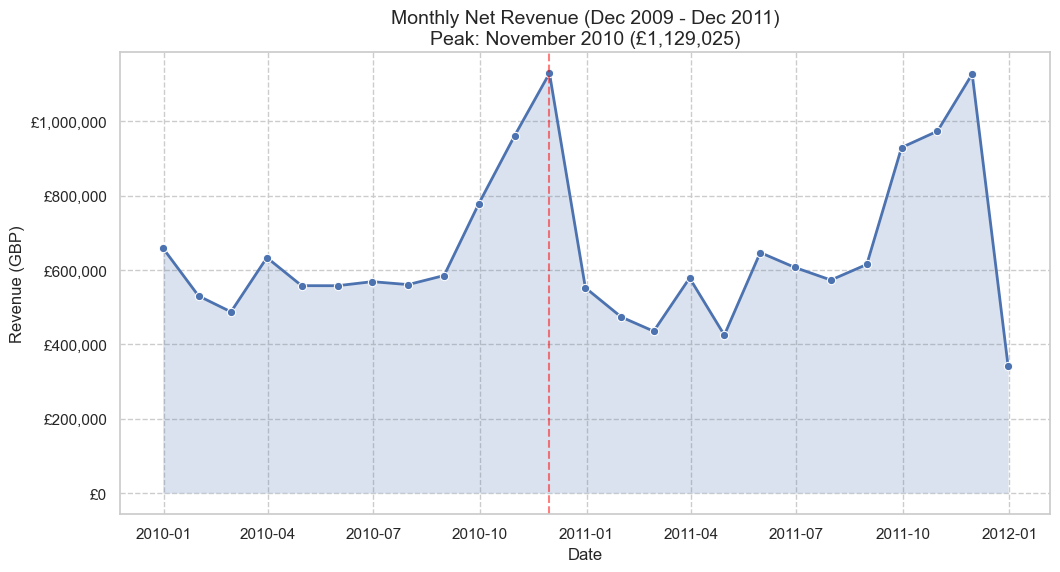

In [6]:
# Monthly revenue aggregation
monthly_revenue = retail_df.set_index('InvoiceDate')['TotalSum'].resample('ME').sum()

# Calculate peak metrics
peak_revenue = monthly_revenue.max()
peak_month = monthly_revenue.idxmax()

sns.lineplot(x=monthly_revenue.index,y=monthly_revenue.values,marker='o',linewidth=2)

plt.title(f'Monthly Net Revenue (Dec 2009 - Dec 2011)\nPeak: {peak_month.strftime('%B %Y')} (£{peak_revenue:,.0f})')
plt.xlabel('Date')
plt.ylabel('Revenue (GBP)')

plt.fill_between(monthly_revenue.index, monthly_revenue.values, alpha=0.2)
plt.axvline(peak_month, color='red', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('£{x:,.0f}')
)

plt.grid(True, linestyle='--')
plt.savefig("../reports/figures/monthly_revenue.png", bbox_inches="tight")
plt.show()

The business shows strong Q4 seasonality with revenue peaking in November. January typically sees a post-holiday dip. This seasonality must be accounted for in our churn model to avoid misclassifying "seasonal shoppers" as "churned customers."

### 3.2 Transaction Type Distribution
**Objective**: Evaluate operational quality by analyzing the distribution of transaction types.

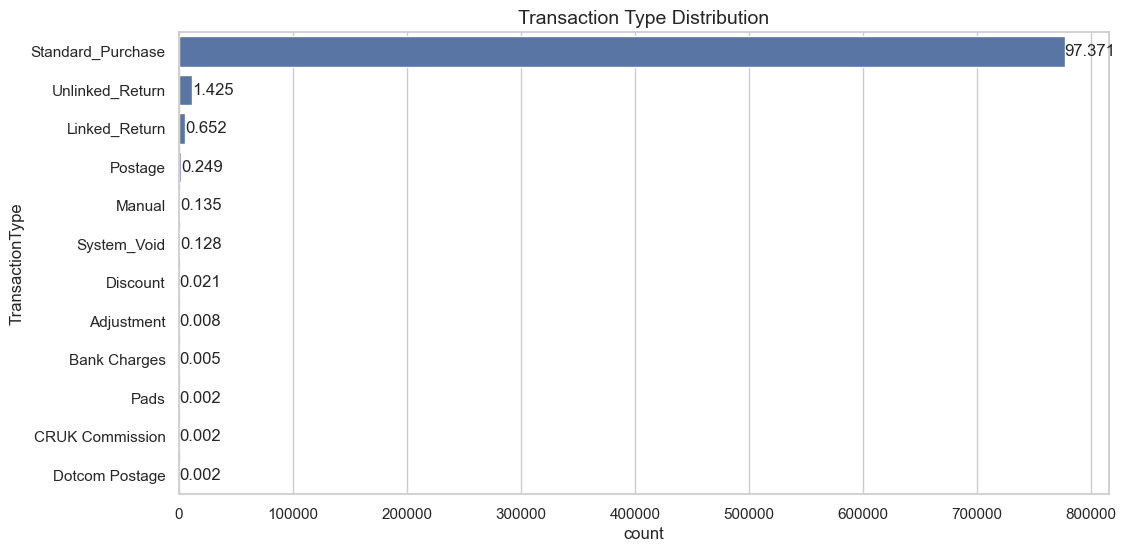

In [7]:
transaction_counts = retail_df['TransactionType'].value_counts(normalize=True)
transaction_percentages = round(transaction_counts * 100, 3)
ax = sns.countplot(
    data=retail_df,
    y='TransactionType',
    order=transaction_counts.index
)
ax.bar_label(container=ax.containers[0], labels=transaction_percentages)

plt.title('Transaction Type Distribution')
plt.show()

**Transaction Type Definitions**:
- **Standard Purchases**: Regular completed sales
- **Linked Returns**: Returns matched to an original purchase within 30 days
- **Unlinked Returns**: Returns without a matched purchase (limited historical data, missing customer IDs, or split returns)
- **System Voids**: Corrections to failed orders—when an initial transaction fails (e.g., payment declined, technical error) and is successfully completed within 60 minutes, the failed attempt is voided.
 
**Interpretation**::
- Standard Purchases dominate (>97% of transactions)
- Unlinked Returns (~1.4%) indicate data limitations (missing historical matches)
- Linked Returns (~0.7%) represent genuine product dissatisfaction
- System Voids represent operational corrections, not customer dissatisfaction—a customer with many voids may simply have experienced technical issues during checkout but still successfully completed their purchase.

**Why This Matters for Churn Modeling**:
Separating return types reduces analytical noise. A customer with many System Voids isn't necessarily dissatisfied—they may have simply encountered temporary payment issues. However, Linked Returns signal potential product/service issues and are a stronger churn indicator. This distinction is critical for building a robust churn model.

### 3.3 Geographic Revenue Distribution
**Objective**: Identify core markets and assess geography's role in segmentation.

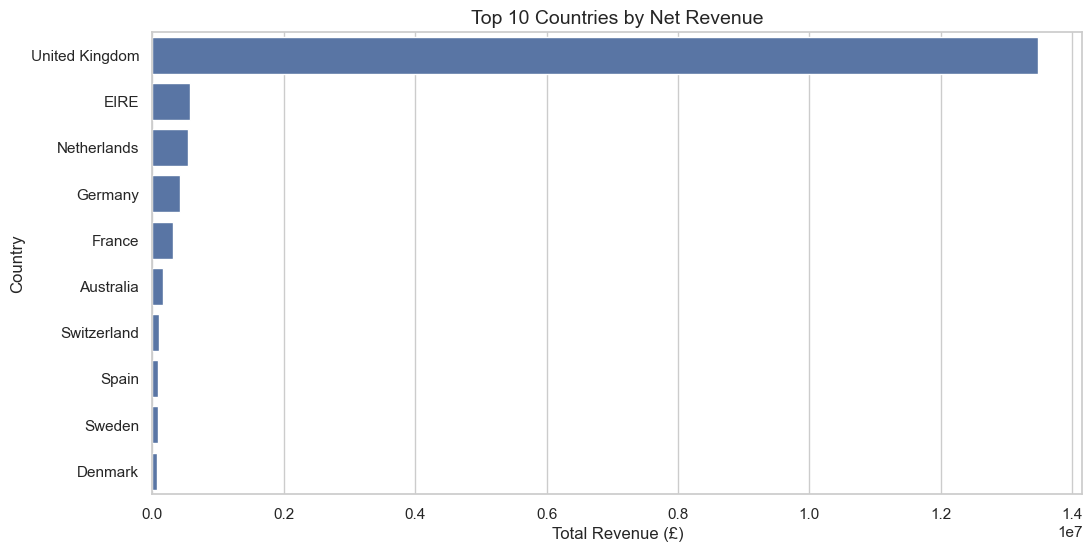

In [8]:
top_10_countries = retail_df.groupby('Country', observed=True)['TotalSum'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10) \
    .reset_index()
top_10_countries['Country'] = top_10_countries['Country'].cat.remove_unused_categories()

sns.barplot(
    data=top_10_countries,
    x='TotalSum',
    y='Country',
    order=top_10_countries['Country'],
)
plt.title('Top 10 Countries by Net Revenue')
plt.xlabel('Total Revenue (£)')
plt.savefig("../reports/figures/top_countries_revenue.png", bbox_inches="tight")
plt.show()

In [9]:
print(f"UK revenue in percentage: {(top_10_countries['TotalSum'][0] / top_10_countries['TotalSum'].sum()):.0%}")

UK revenue in percentage: 85%


The UK dominates revenue (~85%). To ensure consistent behavioral patterns, the remainder of this analysis focuses exclusively on the UK market. This decision reduces confounding factors such as international shipping delays, varying return policies, and cross-country purchasing behavior, allowing for a more controlled analysis of customer churn dynamics.

In [10]:
uk_df = retail_df[retail_df['Country'] == 'United Kingdom'].copy()
print(f"UK customers: {uk_df['CustomerID'].nunique():,}")
print(f"UK transactions: {len(uk_df):,}")
print(f"UK revenue: £{uk_df['TotalSum'].sum():,.2f}")

UK customers: 5,407
UK transactions: 716,069
UK revenue: £13,482,505.09


## 4. UK Customer Deep Dive

### 4.1 RFM Analysis & Churn Definition

#### 4.1.1 Interpurchase Time Analysis

Zero-day intervals: 95.9%


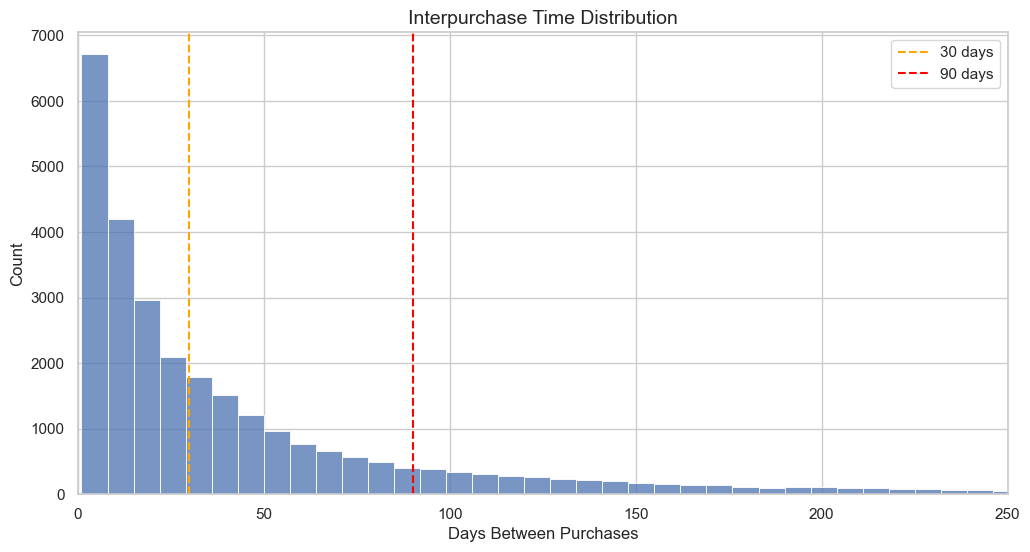

In [11]:
# Sort transactions
uk_df = uk_df.sort_values(['CustomerID', 'InvoiceDate'])

# Compute interpurchase time
uk_df['PrevPurchase'] = uk_df.groupby('CustomerID')['InvoiceDate'].shift(1)
uk_df['InterpurchaseDays'] = (uk_df['InvoiceDate'] - uk_df['PrevPurchase']).dt.days

# Drop nulls and remove same-day transactions
interpurchase = uk_df['InterpurchaseDays'].dropna()
zero_pct = (interpurchase == 0).mean()
print(f"Zero-day intervals: {zero_pct:.1%}")

interpurchase = interpurchase[interpurchase > 0]

# Plot
sns.histplot(interpurchase, bins=100)
plt.title("Interpurchase Time Distribution")
plt.xlabel("Days Between Purchases")
plt.xlim(0, 250)

# Threshold lines
plt.axvline(30, color='orange', linestyle='--', label='30 days')
plt.axvline(90, color='red', linestyle='--', label='90 days')
plt.legend()

plt.show()

To ground the churn definition in actual customer behavior, we analyze the distribution of interpurchase times (the number of days between consecutive purchases).

A significant portion of intervals occur within the same day, driven by operational factors such as split orders or multiple invoices per purchase session. These are excluded to focus on true customer revisit behavior.

The resulting distribution is highly right-skewed: most repeat purchases occur shortly after the previous transaction, followed by a steady decline in return probability.

While some customers return after longer gaps, intervals beyond 90 days lie deep in the tail of the distribution, indicating that such behavior is relatively uncommon. This provides a behavioral foundation for defining churn based on prolonged inactivity.

#### 4.1.2 RFM Calculation

In [12]:
snapshot_date = uk_df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = uk_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda date: (snapshot_date - date.max()).days, # Recency
    'Invoice': 'nunique',                                          # Frequency
    'TotalSum': 'sum'                                              # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

# Handle negative monetary customers
negative_count = (rfm['Monetary'] <= 0).sum()
print(f"Customers with negative balance: {negative_count} ({negative_count/len(rfm):.1%})")

rfm = rfm[rfm['Monetary'] > 0].copy()

Customers with negative balance: 89 (1.6%)


#### 4.1.3 Threshold Sensitivity Analysis

In [13]:
thresholds = [30, 60, 90, 120, 180]
for days in thresholds:
    churn_rate = (rfm['Recency'] > days).mean()
    print(f"{days:3d} days: {churn_rate:.1%} churned")

 30 days: 71.5% churned
 60 days: 58.6% churned
 90 days: 50.5% churned
120 days: 46.7% churned
180 days: 40.5% churned


The churn rate decreases non-linearly as the inactivity threshold increases. Short thresholds (e.g., 30 days) classify a large proportion of customers as churned, likely capturing normal variability in purchase timing rather than true disengagement.

Longer thresholds (e.g., 180 days) are more conservative but delay the identification of at-risk customers.

However, threshold selection should not rely solely on class balance. The interpurchase time analysis shows that most customers who return do so well within 90 days, with longer inactivity periods becoming increasingly rare.

Therefore, a 90-day threshold provides a behaviorally meaningful cutoff while maintaining a reasonable balance between early detection and stability.

#### 4.1.4 Final Churn Definition

In [14]:
CHURN_THRESHOLD = 90
rfm['IsChurned'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

print(f"Selected Threshold: {CHURN_THRESHOLD} days")
print(f"\nClass balance")
print("-"*20)
print(f"Active: {1 - rfm['IsChurned'].mean():.1%}")
print(f"Churned: {rfm['IsChurned'].mean():.1%}")

Selected Threshold: 90 days

Class balance
--------------------
Active: 49.5%
Churned: 50.5%


#### Limitations of the Static Churn Definition

The churn definition used in this EDA is based on a fixed 90-day inactivity threshold applied at the end of the observation period. While this provides a clear and interpretable framework, it introduces several important limitations:

- **Right-censoring bias**: Customers near the end of the dataset have less opportunity to exhibit future activity, potentially inflating churn estimates.
- **Snapshot dependency**: Churn is defined at a single point in time rather than as a dynamic process.
- **Seasonality distortion**: Customers with irregular or seasonal purchasing patterns may be incorrectly labeled as churned during natural inactivity periods.
- **Lack of temporal realism**: This definition does not reflect how churn would be predicted in a real-time production setting.

To address these limitations, subsequent stages will adopt a **time-based sliding window approach**, where churn is defined relative to future activity within each observation window.

Despite these constraints, the current definition is sufficient for identifying key behavioral patterns and generating hypotheses for modeling.

### 4.2 RFM Distribution Analysis

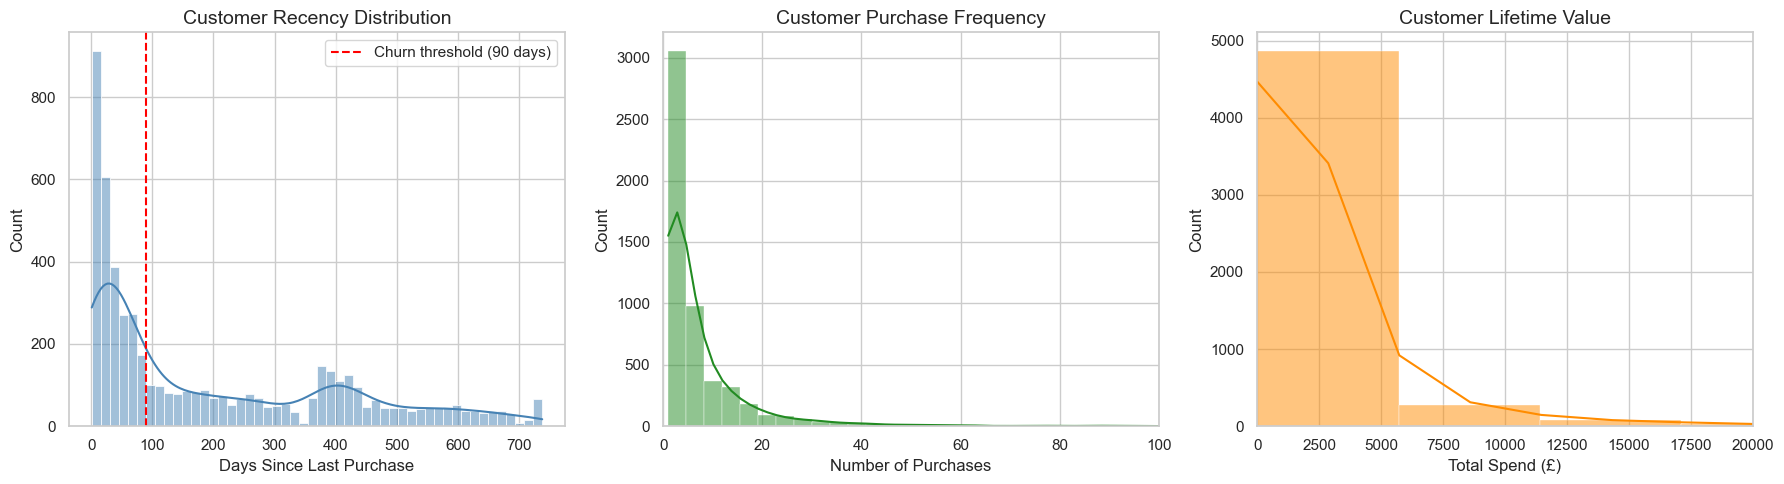

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(data=rfm, x='Recency', bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(CHURN_THRESHOLD, color='red', linestyle='--', label=f'Churn threshold ({CHURN_THRESHOLD} days)')
axes[0].set_title('Customer Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].legend()

sns.histplot(data=rfm, x='Frequency', bins=100, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_xlim(0, 100) 
axes[1].set_title('Customer Purchase Frequency')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(data=rfm, x='Monetary', bins=100, kde=True, ax=axes[2], color='darkorange')
axes[2].set_xlim(0, 20000)
axes[2].set_title('Customer Lifetime Value')
axes[2].set_xlabel('Total Spend (£)')

plt.tight_layout()
plt.savefig("../reports/figures/rfm_distribution.png", bbox_inches="tight")
plt.show()

These RFM plots clearly show a highly right-skewed customer base.

Recency indicates a strong concentration of customers below the 90-day threshold, but with a long disengaged tail, suggesting a substantial at-risk segment. Frequency is heavily skewed, with most customers making very few purchases and a small group of highly active buyers. Monetary value follows the same pattern, where a minority of customers generate disproportionately high revenue.

Overall, this confirms a structure where many customers have low engagement while a relatively small group accounts for most activity and revenue. This supports segmentation and suggests churn risk will likely concentrate among low-frequency, low-monetary customers.

#### One-time Customer Analysis

In [16]:
one_time = (rfm['Frequency'] == 1).mean()
print(f"Customer Segmentation:")
print(f"  One-time customers: {one_time:.1%}")
print(f"  Repeat customers: {1-one_time:.1%}")

Customer Segmentation:
  One-time customers: 24.1%
  Repeat customers: 75.9%


### 4.2.1 RFM Correlation Analysis

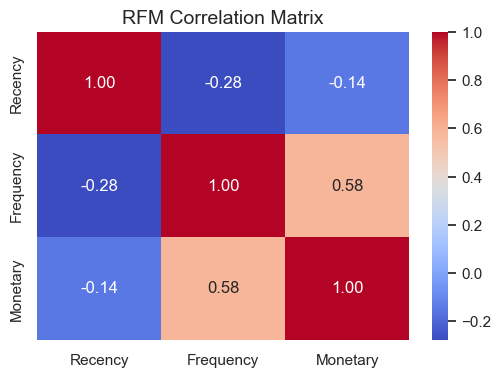

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("RFM Correlation Matrix")
plt.show()

**Feature Relationships**

Frequency and Monetary show a moderate positive correlation (0.58), indicating that more active customers tend to generate higher revenue, though both variables still capture distinct aspects of behavior.

Recency is only weakly correlated with Frequency (-0.28) and Monetary (-0.14), suggesting that recent activity is not strongly tied to overall engagement or customer value.

Overall, the RFM components provide complementary information with limited redundancy, making them well-suited for modeling.

## 4.3 RFM Segmentation & Analysis

RFM (Recency, Frequency, Monetary) segmentation is a powerful technique for understanding customer behavior and identifying distinct customer groups based on their purchasing patterns. This analysis will help us develop targeted retention strategies for each segment.

### 4.3.1 RFM Score Calculation

First, we calculate RFM scores by dividing customers into quintiles for each dimension. Note that Recency is reverse-scored (lower days since last purchase is better), while Frequency and Monetary are scored normally (higher values are better).

In [18]:
rfm_seg = rfm.copy()

# Calculate Recency score (lower recency = higher score)
rfm_seg['R_Score'] = pd.qcut(
    rfm_seg['Recency'], 
    q=5, 
    labels=[5, 4, 3, 2, 1], 
    duplicates='drop'
).astype(int)

# Calculate Frequency score (higher frequency = higher score)
rfm_seg['F_Score'] = pd.qcut(
    rfm_seg['Frequency'].rank(method='first'), 
    q=5, 
    labels=[1, 2, 3, 4, 5], 
    duplicates='drop'
).astype(int)

# Calculate Monetary score (higher monetary = higher score)
rfm_seg['M_Score'] = pd.qcut(
    rfm_seg['Monetary'], 
    q=5, 
    labels=[1, 2, 3, 4, 5], 
    duplicates='drop'
).astype(int)

### 4.3.2 Segment Definition

Based on the RFM scores, we assign customers to strategic segments using business-defined rules. These segments help identify high-value customers, at-risk groups, and opportunities for targeted interventions.

In [19]:
# Define segment mapping function
def get_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    
    # High-value segments
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if f >= 4 and m >= 4:
        return 'Loyal'
    if r >= 4 and f >= 3 and m >= 3:
        return 'Potential Loyalists'
    
    # At-risk segments
    if r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    if r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    
    # Low engagement segments
    if r >= 3 and (f <= 2 or m <= 2):
        return 'Need Attention'
    if r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    
    # Other segments
    if r >= 4:
        return 'New Customers'
    
    return 'Other'

# Apply segmentation
rfm_seg['Segment'] = rfm_seg.apply(get_segment, axis=1)

# Create segment summary
segment_summary = rfm_seg.groupby('Segment').agg({
    'CustomerID': 'count',
    'IsChurned': 'mean',
    'R_Score': 'mean',
    'F_Score': 'mean',
    'M_Score': 'mean'
}).round(2).rename(columns={
    'CustomerID': 'Count', 
    'IsChurned': 'Churn_Rate'
})

# Display segment summary
print("RFM SEGMENT ANALYSIS")
print("-"*70)
print(segment_summary.sort_values('Churn_Rate', ascending=False).to_string())

# Save
segment_summary.to_csv('../reports/rfm_segment_analysis.csv')

RFM SEGMENT ANALYSIS
----------------------------------------------------------------------
                     Count  Churn_Rate  R_Score  F_Score  M_Score
Segment                                                          
At Risk                364        1.00     1.65     3.25     3.30
Hibernating           1171        1.00     1.40     1.41     1.40
Other                  631        0.84     2.12     2.78     2.86
Loyal                  586        0.68     2.55     4.40     4.43
Need Attention         972        0.23     3.76     1.94     1.91
Champions             1170        0.00     4.59     4.69     4.66
Potential Loyalists    424        0.00     4.44     3.34     3.30


### 4.3.3 Segment Visualization

Visualizing segment sizes and churn rates provides immediate insights into the distribution of customer types and their associated risk levels.

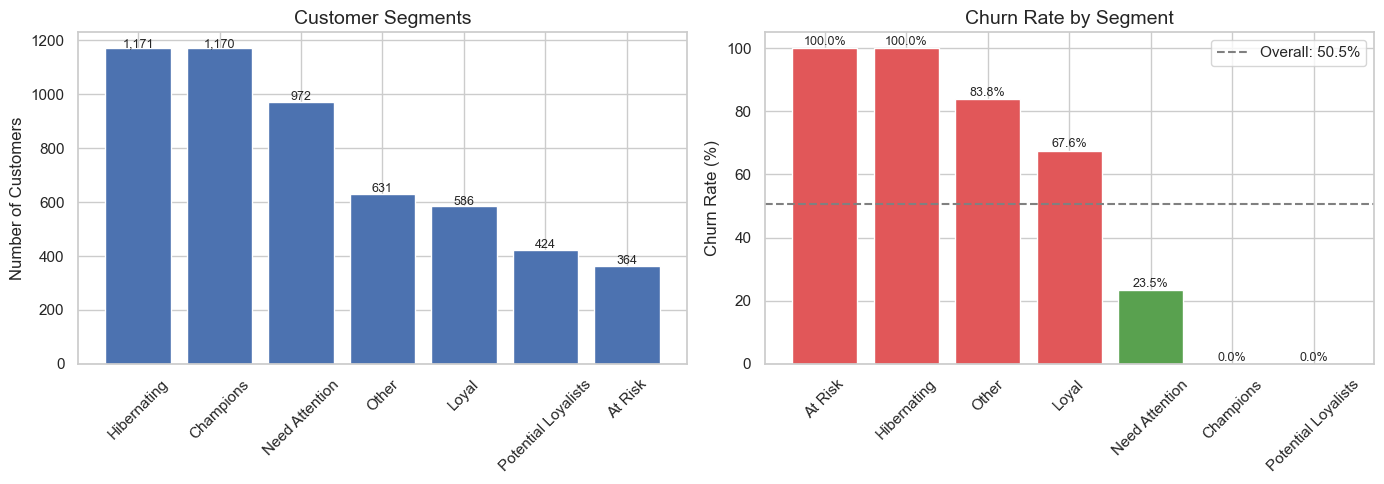

In [20]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Segment size distribution
seg_counts = rfm_seg['Segment'].value_counts()
bars = axes[0].bar(seg_counts.index, seg_counts.values)
axes[0].set_title('Customer Segments')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for bar, val in zip(bars, seg_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 5, 
        f'{val:,}', 
        ha='center', 
        fontsize=9
    )

# Plot 2: Churn rate by segment
churn_by_seg = rfm_seg.groupby('Segment')['IsChurned'].mean().sort_values(ascending=False)
colors = ['#E15759' if x > 0.5 else '#59A14F' for x in churn_by_seg.values]
bars = axes[1].bar(churn_by_seg.index, churn_by_seg.values * 100, color=colors)
axes[1].axhline(
    y=rfm['IsChurned'].mean() * 100, 
    color='gray', 
    linestyle='--', 
    label=f'Overall: {rfm["IsChurned"].mean()*100:.1f}%'
)
axes[1].set_title('Churn Rate by Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Add value labels
for bar, val in zip(bars, churn_by_seg.values * 100):
    axes[1].text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 1, 
        f'{val:.1f}%', 
        ha='center', 
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Insights**:
- Loyal segment is the largest (586 customers) but shows 67.6% churn
- Champions and Potential Loyalists have 0% churn as expected
- At Risk and Hibernating show expected 100% churn rates
- The Loyal segment's high churn rate is the only anomaly requiring deeper investigation

## 4.4 Seasonality Validation: Investigating Loyal Segment Churn

### 4.4.1 Analysis Overview

Given the unexpected 67.6% churn rate in the Loyal segment, we conduct a seasonality analysis to test whether this is true attrition or a definition artifact caused by the static 90-day inactivity window.

### 4.4.2 Data Preparation

In [21]:
# Add the Month and IsQ4 columns
uk_df['Month'] = uk_df['InvoiceDate'].dt.month
uk_df['IsQ4'] = uk_df['Month'].isin([10, 11, 12])

# Merge segment data with transaction data
segment_transactions = uk_df.merge(rfm_seg[['CustomerID', 'Segment']], on='CustomerID')
segment_transactions['Month'] = segment_transactions['InvoiceDate'].dt.month

# Calculate the monthly by segment
monthly_by_segment = (segment_transactions.groupby(['Segment', 'Month'])
                     .size()
                     .reset_index(name='Count'))
monthly_by_segment['Pct'] = (monthly_by_segment.groupby('Segment')['Count']
                            .transform(lambda x: x / x.sum() * 100))

# Calculate Q4 concentration per customer
q4_concentration = segment_transactions.groupby(['CustomerID', 'Segment'])['IsQ4'].mean().reset_index()
q4_concentration.columns = ['CustomerID', 'Segment', 'Q4_Concentration']


# Define segment order and colors
segment_order = ['At Risk', 'Hibernating', 'Other', 'Loyal', 'Need Attention', 'Champions', 'Potential Loyalists']

segment_colors = {
    'At Risk': '#E15759',
    'Hibernating': '#F28E2B',
    'Other': '#808080',
    'Loyal': '#4E79A7',
    'Need Attention': '#59A14F',
    'Champions': '#B07AA1',
    'Potential Loyalists': '#FF9DA7'
}

### 4.4.3 Seasonal Purchase Profile Analysis

This analysis examines the monthly purchase distribution across segments to identify seasonal patterns.

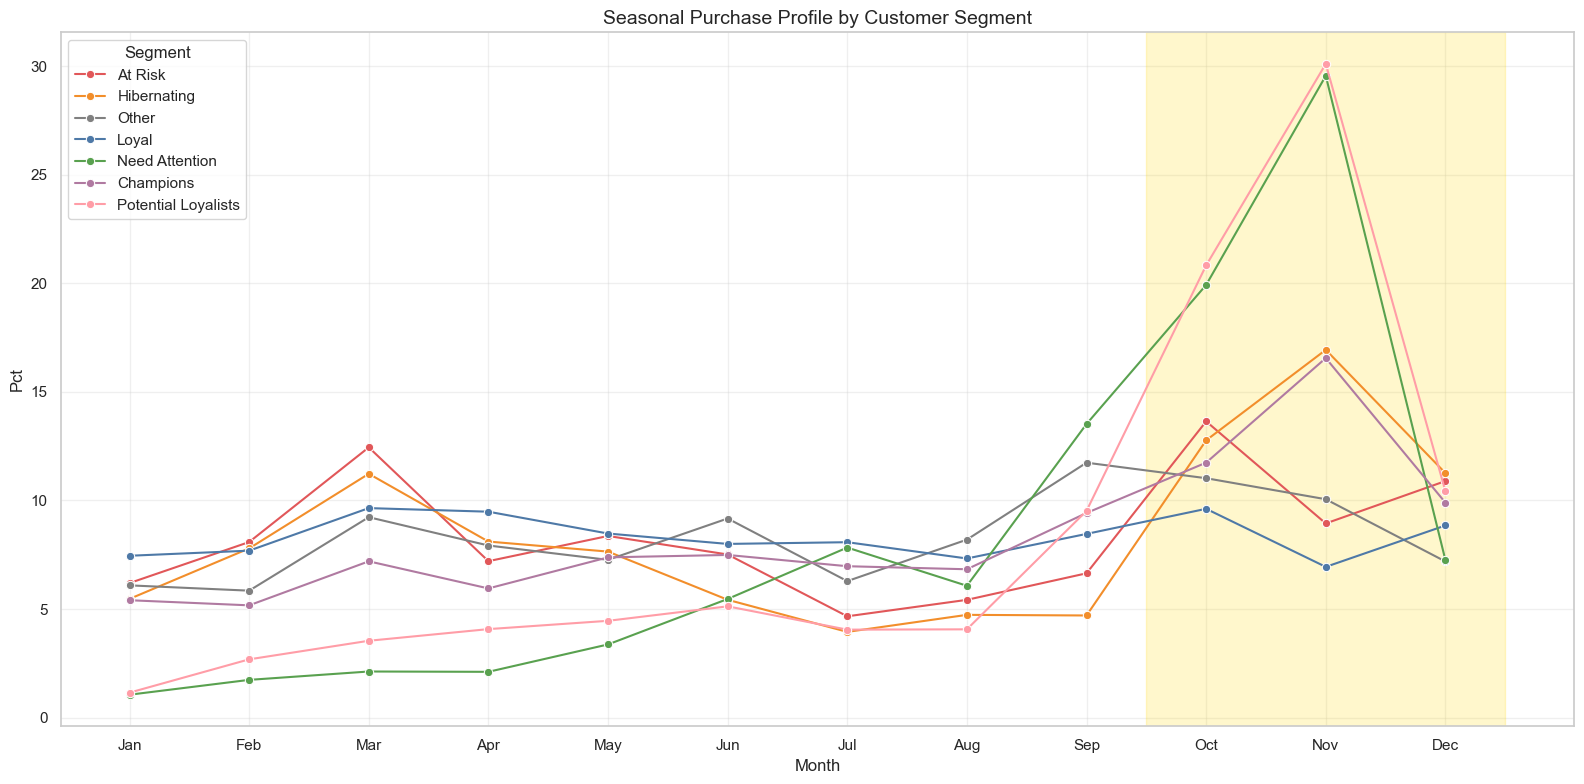

In [22]:
# Create plot
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_by_segment,
             x='Month',
             y='Pct',
             hue='Segment',
             hue_order=segment_order,
             palette=segment_colors,
             marker='o')

# Add Q4 highlight
plt.axvspan(9.5, 12.5, alpha=0.2, color='gold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Seasonal Purchase Profile by Customer Segment')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The Loyal segment shows the flattest seasonal profile of all segments, with purchases evenly distributed throughout the year (7-9.5% per month). This is the opposite pattern of seasonal shoppers, suggesting these customers are consistent year-round purchasers who likely churned due to timing of the 90-day window, not actual attrition.

### 4.4.4 Q4 Concentration Analysis

To quantify seasonality at the individual customer level, we calculate the proportion of each customer's purchases occurring in Q4 (Oct-Dec).

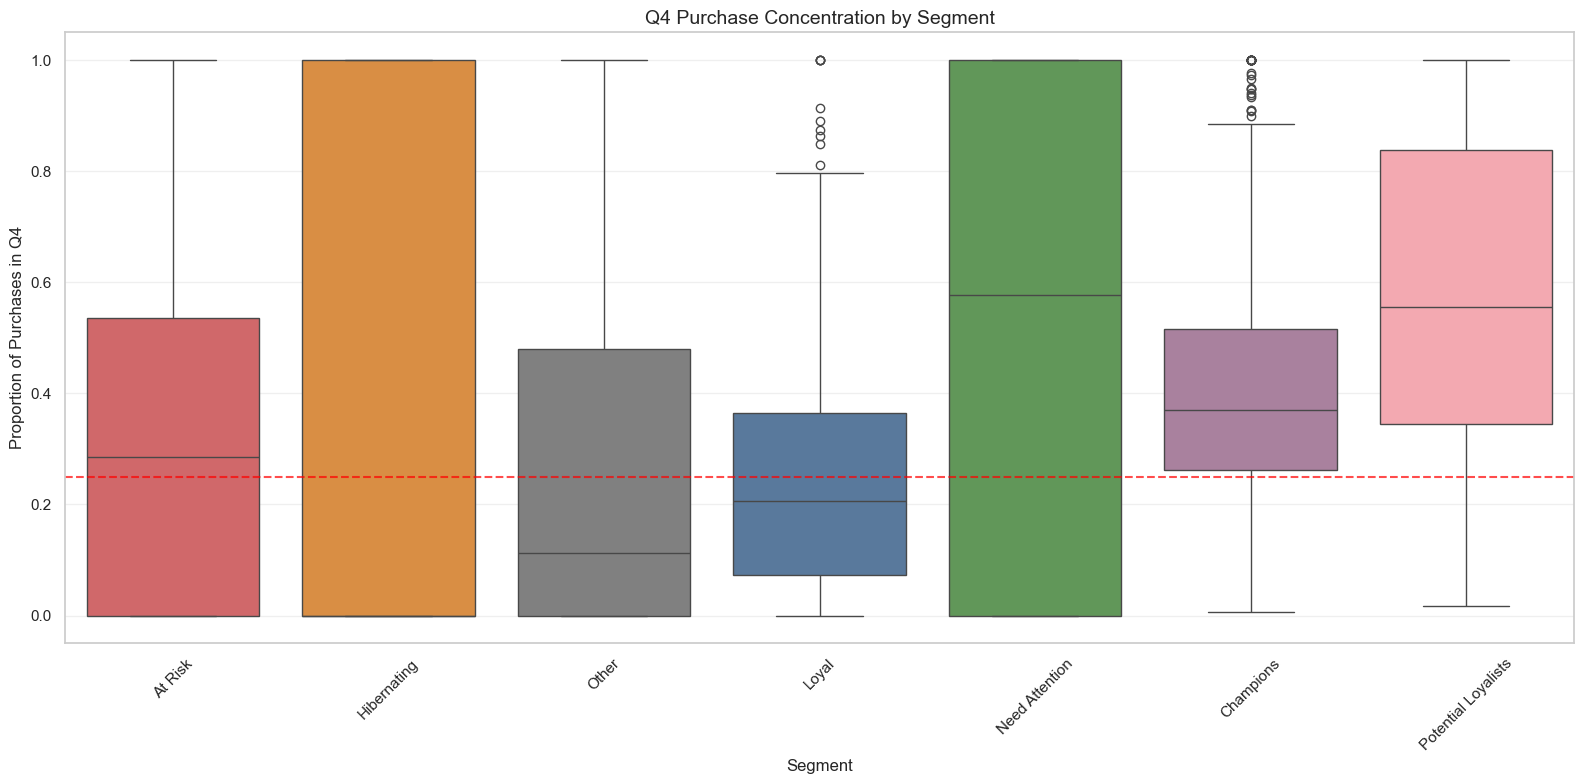

In [23]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=q4_concentration, 
            x='Segment', 
            y='Q4_Concentration',
            order=segment_order,
            hue='Segment',
            palette=segment_colors,
            legend=False)

# Reference line
plt.axhline(y=0.25, color='red', linestyle='--', alpha=0.7)

# Formatting
plt.ylabel('Proportion of Purchases in Q4')
plt.title('Q4 Purchase Concentration by Segment')
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

The Loyal segment has the lowest Q4 concentration (38%) among all active segments. This confirms they are not seasonal shoppers but rather consistent year-round buyers. A 90-day inactivity window will inevitably catch these customers between purchase cycles, leading to false churn classification.

### 4.4.5 Segment Renaming Based on Behavioral Insights

Based on the seasonality analysis above, we rename segments to more accurately reflect their purchasing behavior. The original "Loyal" segment name implied low churn expectation, but we've demonstrated their 67.6% churn rate is a definition artifact, not true attrition. Similarly, "Potential Loyalists" suggests a path to loyalty, but their extreme seasonality makes them a distinct segment.


In [24]:
# Define renaming mapping
segment_rename = {
    'Loyal': 'Consistent Buyers',                  # Year-round purchasers, not seasonal
    'Potential Loyalists': 'Seasonal High-Value',  # Extreme Q4 concentration
    'Champions': 'VIP'                             # High-value, premium customers
}

# Apply renaming to all relevant dataframes
rfm_seg['Segment'] = rfm_seg['Segment'].replace(segment_rename)
q4_concentration['Segment'] = q4_concentration['Segment'].replace(segment_rename)
monthly_by_segment['Segment'] = monthly_by_segment['Segment'].replace(segment_rename)

# Update segment order for visualization
segment_order = ['At Risk', 'Hibernating', 'Other', 'Consistent Buyers', 
                 'Need Attention', 'VIP', 'Seasonal High-Value']

# Update color mapping for renamed segments
segment_colors = {
    'At Risk': '#E15759',
    'Hibernating': '#F28E2B',
    'Other': '#808080',
    'Consistent Buyers': '#4E79A7',       # Formerly Loyal
    'Need Attention': '#59A14F',
    'VIP': '#B07AA1',                     # Formerly Champions
    'Seasonal High-Value': '#FF9DA7'      # Formerly Potential Loyalists
}

## 4.5 Churned vs. Active Comparison

> ⚠️ Important Note on Recency and Data Leakage
>
> Recency is directly used in the definition of churn (customers are labeled as churned if their recency exceeds 90 days). As a result, the strong separation observed in Recency between churned and active customers is expected and should not be interpreted as an independent predictive signal.
>
> In subsequent modeling, care will be taken to avoid data leakage by ensuring that all features are computed strictly within the observation window and do not incorporate future information.

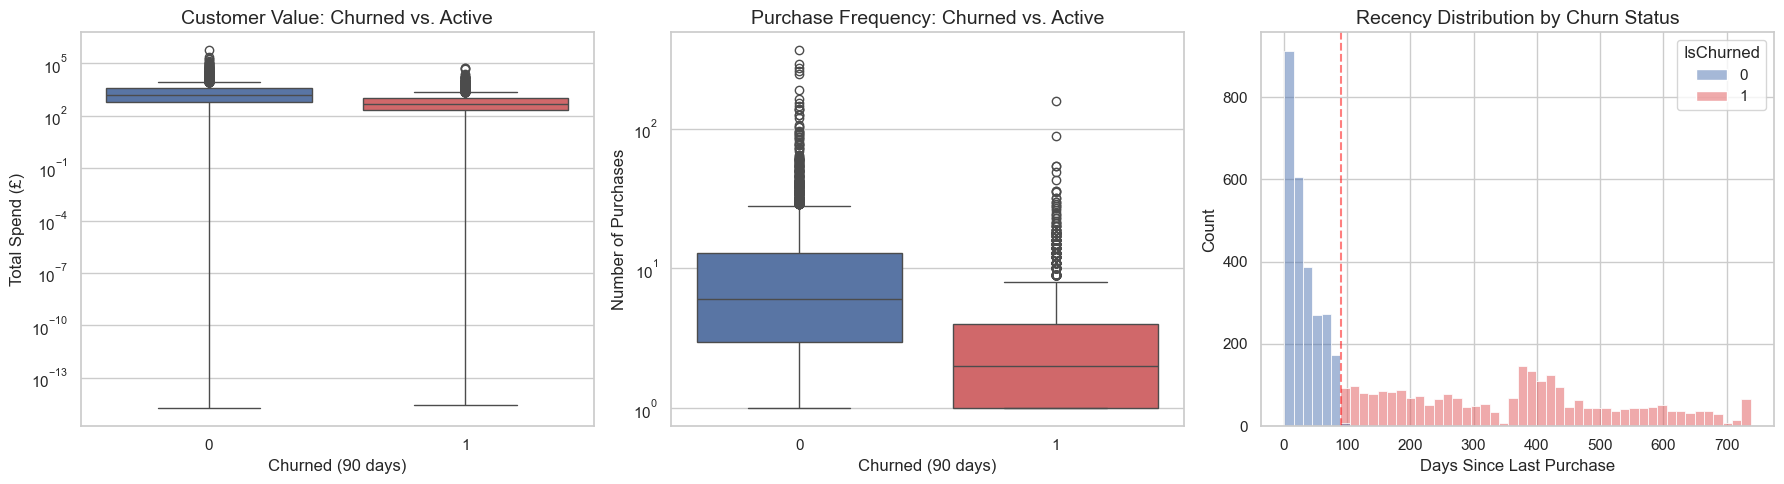

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monetary value comparison
sns.boxplot(
    data=rfm,
    x='IsChurned',
    y='Monetary',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Customer Value: Churned vs. Active')
axes[0].set_xlabel(f'Churned ({CHURN_THRESHOLD} days)')
axes[0].set_ylabel('Total Spend (£)')

# Frequency comparison
sns.boxplot(
    data=rfm,
    x='IsChurned',
    y='Frequency',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Purchase Frequency: Churned vs. Active')
axes[1].set_xlabel(f'Churned ({CHURN_THRESHOLD} days)')
axes[1].set_ylabel('Number of Purchases')

# Recency distribution by churn status
sns.histplot(
    data=rfm,
    x='Recency',
    hue='IsChurned',
    bins=50,
    palette=CHURN_PALETTE,
    ax=axes[2]
)
axes[2].axvline(CHURN_THRESHOLD, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('Recency Distribution by Churn Status')
axes[2].set_xlabel('Days Since Last Purchase')

plt.tight_layout()
plt.show()

These plots show clear behavioral separation between churned and active customers.

Churned customers exhibit lower monetary value and significantly lower purchase frequency, with medians visibly below active customers. The frequency gap is particularly strong, suggesting engagement intensity is a key differentiator. Recency shows almost perfect separation due to the 90-day rule, confirming it is structurally tied to the churn definition.

Overall, churn is strongly associated with low frequency and lower spend, indicating that disengagement precedes attrition. Frequency appears to be the most informative non-leakage predictor among RFM variables.

## 4.6 Temporal Behavior & Engagement Dynamics

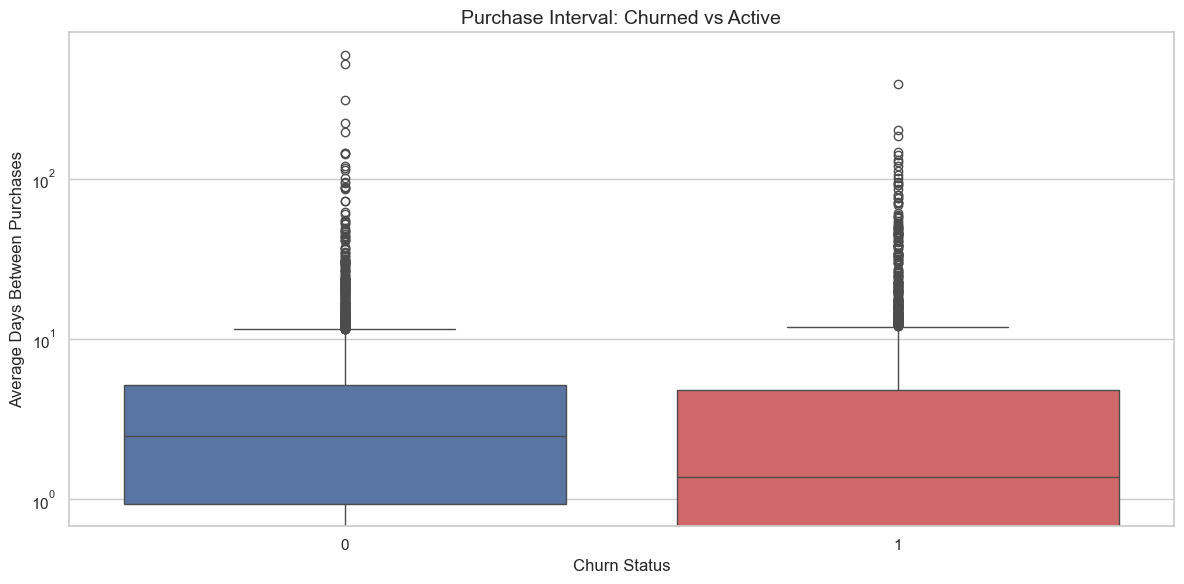

In [26]:
# Average interpurchase time per customer
purchase_intervals = uk_df.groupby('CustomerID')['InterpurchaseDays'].mean().reset_index()
purchase_intervals.columns = ['CustomerID', 'AvgInterpurchaseDays']

# Merge with churn labels
purchase_intervals = purchase_intervals.merge(
    rfm[['CustomerID', 'IsChurned']], 
    on='CustomerID'
)

# Plot
sns.boxplot(
    data=purchase_intervals,
    x='IsChurned',
    y='AvgInterpurchaseDays',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False
)

plt.yscale('log')
plt.title('Purchase Interval: Churned vs Active')
plt.xlabel('Churn Status')
plt.ylabel('Average Days Between Purchases')

plt.tight_layout()
plt.show()

The difference in average interpurchase time between churned and active customers is modest, with substantial overlap between the two groups. This indicates that average purchase intervals show limited discriminatory power for churn.

This is expected, as churn is defined by recent inactivity, while average interpurchase time reflects historical behavior. Customers who have recently disengaged may still exhibit relatively short historical intervals.

This reinforces the need for features that capture recent activity and behavioral trends rather than relying on historical averages alone.

## 4.7 Behavioral Pattern Analysis

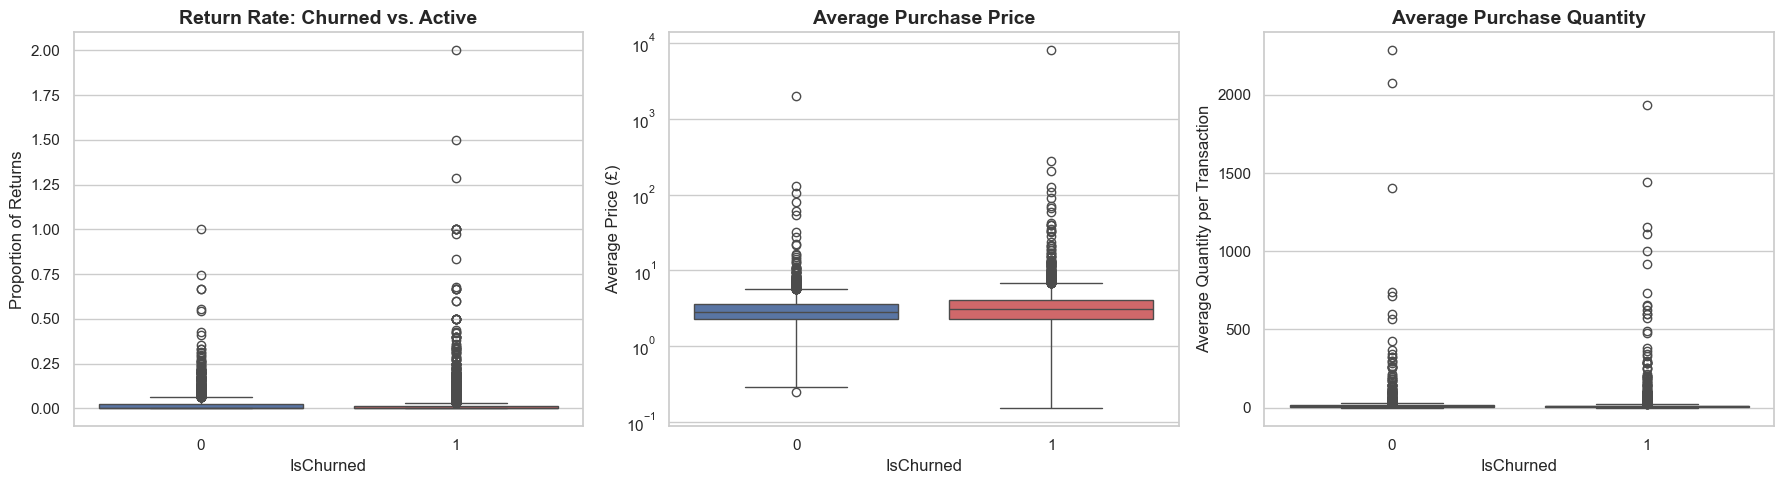

In [27]:
# Calculate behavioral metrics per customer
behavior = uk_df.groupby('CustomerID').agg({
    'Quantity': ['mean', 'sum'],
    'Price': ['mean', 'std'],
    # Only perform the ratio on the Standard Purchases
    'TransactionType': lambda x: (
        x.isin(['Linked_Return', 'Unlinked_Return']).sum() /
        # Avoid division by zero
        max((x == 'Standard_Purchase').sum(), 1)
    )
}).reset_index()

behavior.columns = ['CustomerID', 'AvgQty', 'TotalQty', 'AvgPrice', 'PriceStd', 'ReturnRate']

# Merge with churn labels
behavior = behavior.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Return rate comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='ReturnRate',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Return Rate: Churned vs. Active', fontweight='bold')
axes[0].set_ylabel('Proportion of Returns')

# Average price comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='AvgPrice',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Average Purchase Price', fontweight='bold')
axes[1].set_ylabel('Average Price (£)')

# Quantity comparison
sns.boxplot(
    data=behavior,
    x='IsChurned',
    y='AvgQty',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Average Purchase Quantity', fontweight='bold')
axes[2].set_ylabel('Average Quantity per Transaction')

plt.tight_layout()
plt.show()

Return rate is low overall and does not show strong separation, suggesting returns are not a primary churn driver. Average purchase price is slightly higher for churned customers, but the difference appears modest and likely not structurally important. Average quantity per transaction shows heavy dispersion with no clear distinction between groups.

Overall, engagement intensity (frequency) seems far more predictive than transactional characteristics like price, quantity, or returns. Churn appears driven more by declining activity than by purchasing style.

## 5. Temporal Dynamics

### 5.1 Cohort Analysis
Objective: Track customer retention over time to identify patterns.

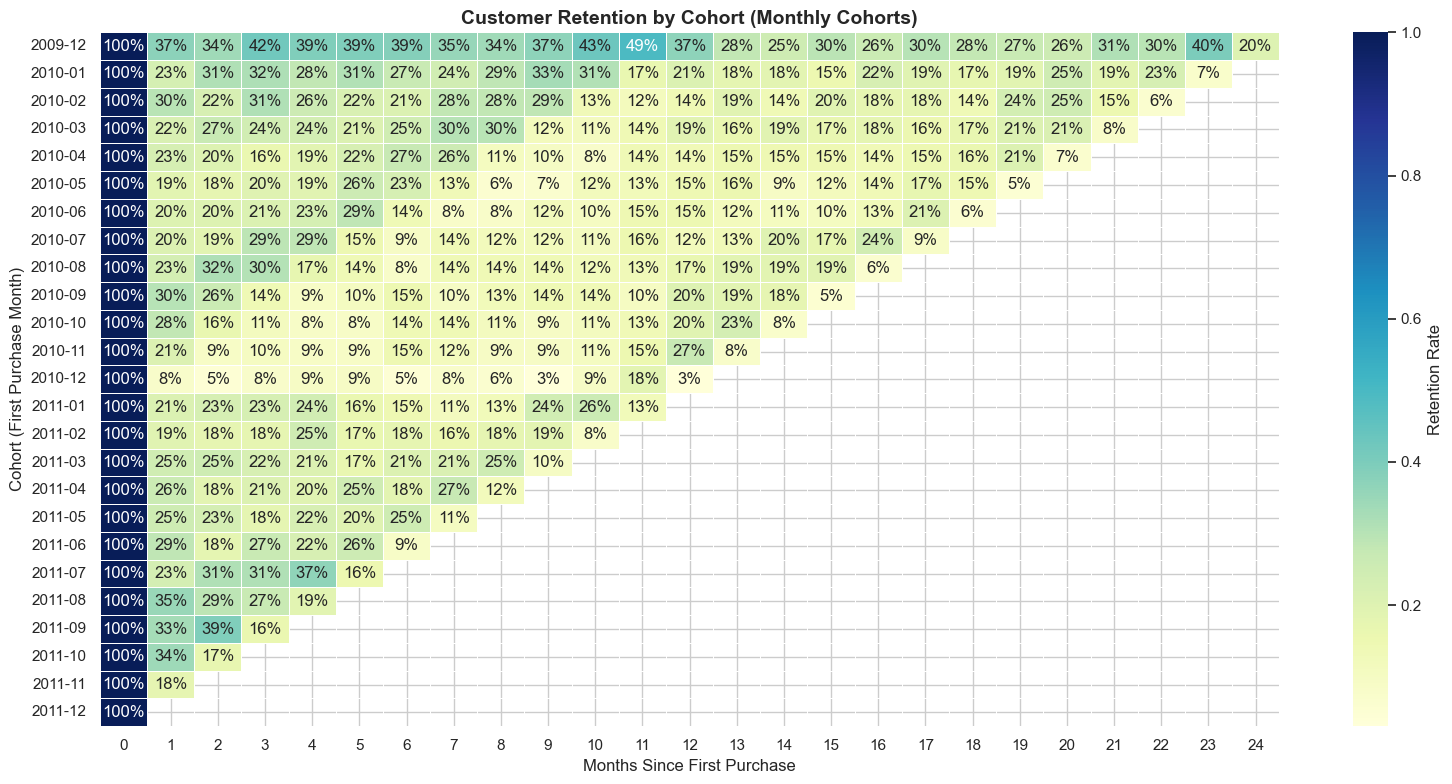

In [28]:
# Create cohort groups
uk_df['InvoiceMonth'] = uk_df['InvoiceDate'].dt.to_period('M')
customer_cohort = uk_df.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
customer_cohort.columns = ['CustomerID', 'CohortMonth']

uk_df = uk_df.merge(customer_cohort, on='CustomerID')
uk_df['CohortIndex'] = (uk_df['InvoiceMonth'] - uk_df['CohortMonth']).apply(lambda x: x.n)

# Build retention matrix
cohort_data = uk_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
retention_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Convert to percentages
cohort_sizes = retention_matrix.iloc[:, 0]
retention_pct = retention_matrix.divide(cohort_sizes, axis=0)

# Plot
plt.figure(figsize=(16, 8))
sns.heatmap(retention_pct, annot=True, fmt='.0%', cmap='YlGnBu', 
            cbar_kws={'label': 'Retention Rate'},
            linewidths=0.5, linecolor='white')

plt.title('Customer Retention by Cohort (Monthly Cohorts)', fontweight='bold', fontsize=14)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

Retention drops sharply after the first month across nearly all cohorts, indicating weak early loyalty and a high proportion of one-time or short-term buyers. After the initial decline, retention stabilizes at relatively low levels, suggesting that customers who survive the first few months are more likely to remain engaged long term.

There is some variability across cohorts, but no clear structural improvement over time.

Overall, the key insight is that churn is heavily front-loaded. Early lifecycle engagement appears critical, making the first 1–3 months the most important intervention window.

### 5.2 Seasonality Analysis
Objective: Quantify the impact of Q4 on purchasing behavior.

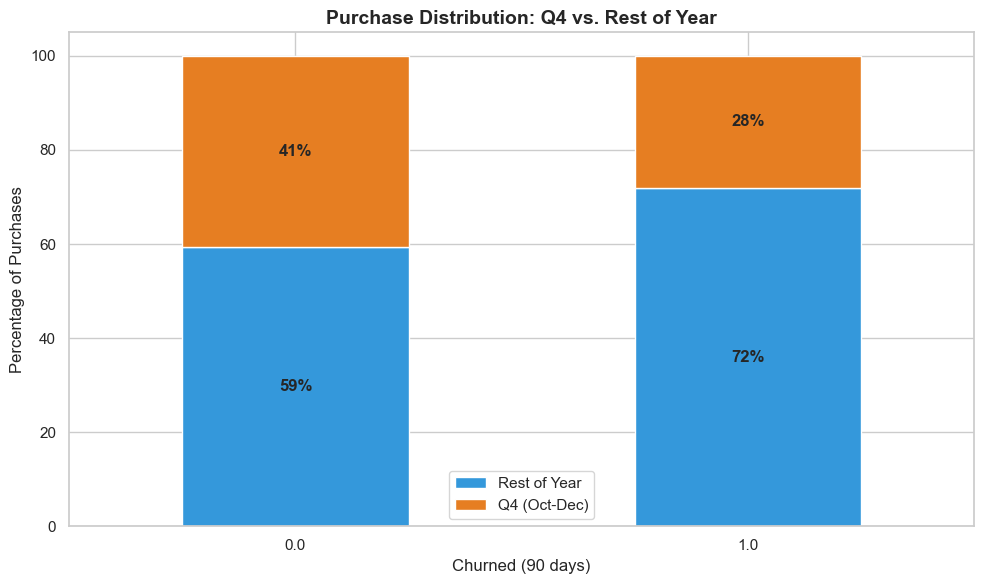

In [29]:
uk_df = uk_df.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID', how='left')

# Calculate Q4 purchase percentage by churn status
q4_by_churn = uk_df.groupby(['IsChurned', 'IsQ4'])['Invoice'].count().unstack()
q4_pct = q4_by_churn.div(q4_by_churn.sum(axis=1), axis=0) * 100

# Plot
ax = q4_pct.plot(kind='bar', stacked=True, color=['#3498db', '#e67e22'], figsize=(10, 6))
plt.title('Purchase Distribution: Q4 vs. Rest of Year', fontweight='bold')
plt.xlabel(f'Churned ({CHURN_THRESHOLD} days)')
plt.ylabel('Percentage of Purchases')
plt.legend(['Rest of Year', 'Q4 (Oct-Dec)'])
plt.xticks(rotation=0)

# Add value labels
for i, (idx, row) in enumerate(q4_pct.iterrows()):
    ax.text(i, row.iloc[0]/2, f"{row.iloc[0]:.0f}%", ha='center', va='center', fontweight='bold')
    ax.text(i, row.iloc[0] + row.iloc[1]/2, f"{row.iloc[1]:.0f}%", ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Active customers (0) have 41% of purchases in Q4, while churned customers (1) have only 28% in Q4. That means active customers are more concentrated in the holiday period, not churned ones.

This suggests that retained customers may be more engaged during peak season and continue purchasing beyond it. Churned customers, on the other hand, appear less tied to Q4 and may represent more sporadic or low-engagement buyers overall.

So the insight shifts: seasonality alone does not explain churn — sustained engagement beyond peak periods likely differentiates active customers.

### 5.3 Customer Tenure Analysis

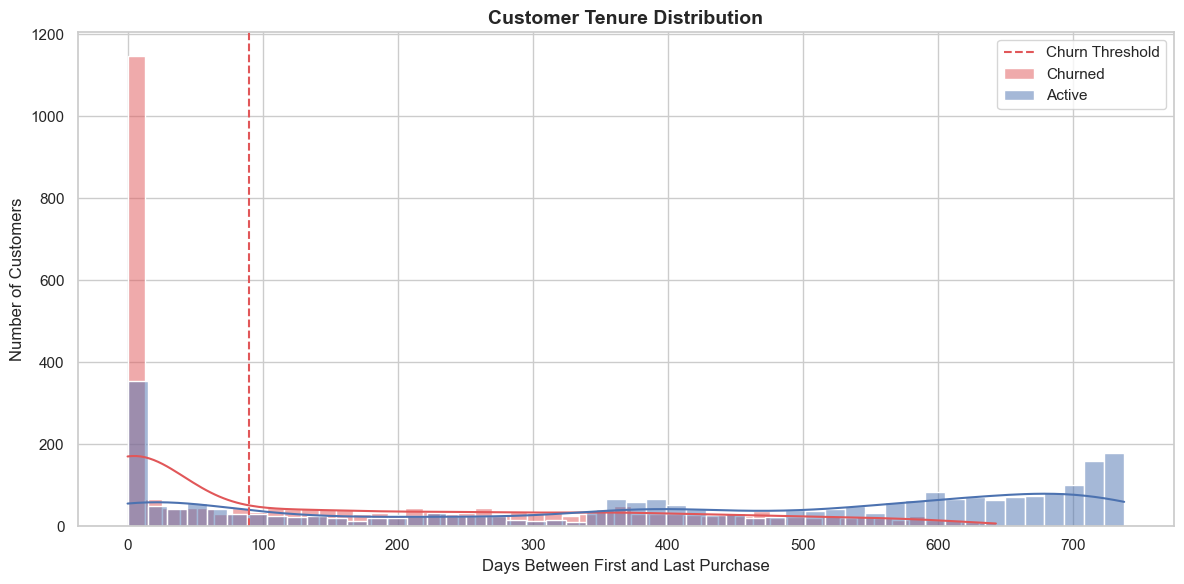

In [30]:
# Calculate customer lifetime
tenure = uk_df.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max']
}).reset_index()
tenure.columns = ['CustomerID', 'FirstPurchase', 'LastPurchase']
tenure['TenureDays'] = (tenure['LastPurchase'] - tenure['FirstPurchase']).dt.days

tenure = tenure.merge(rfm[['CustomerID', 'IsChurned']], on='CustomerID')

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(data=tenure[tenure['IsChurned']==1], x='TenureDays', bins=50, 
             color=COLOR_CHURNED, label='Churned', kde=True)
sns.histplot(data=tenure[tenure['IsChurned']==0], x='TenureDays', bins=50, 
             color=COLOR_RETAINED, label='Active', kde=True)

plt.axvline(CHURN_THRESHOLD, color=COLOR_CHURNED, linestyle='--', label=f'Churn Threshold')
plt.title('Customer Tenure Distribution', fontweight='bold')
plt.xlabel('Days Between First and Last Purchase')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

Churned customers are heavily concentrated at very low tenure, indicating many customers purchase once (or within a short window) and never return. Active customers, in contrast, are more distributed across longer tenures, with a visible concentration at high lifetime durations.

This reinforces the cohort insight: churn is strongly front-loaded. The main risk is early-stage attrition rather than long-term disengagement.

From a business perspective, improving early retention and post-first-purchase engagement would likely have the highest impact.

## 6. Customer Value vs Purchase Frequency

In [31]:
rfm['LogFrequency'] = np.log1p(rfm['Frequency'])
rfm['LogMonetary'] = np.log1p(rfm['Monetary'])

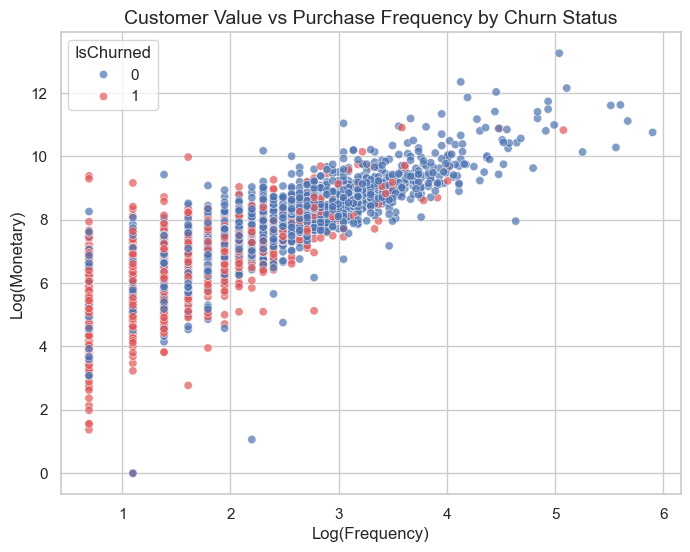

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='LogFrequency',
    y='LogMonetary',
    hue='IsChurned',
    palette=CHURN_PALETTE,
    alpha=0.7
)

plt.title("Customer Value vs Purchase Frequency by Churn Status")
plt.xlabel("Log(Frequency)")
plt.ylabel("Log(Monetary)")
plt.show()

The plot shows a clear positive relationship between purchase frequency and monetary value. Customers who buy more frequently tend to generate higher revenue.

Churned customers are more concentrated in the lower frequency and lower spending region, while higher-value customers are mostly retained. This suggests that purchasing behavior is an important indicator of customer retention.

## 7. Statistical Validation of EDA Findings

While visual analysis suggests meaningful differences between churned and active customers, we formally test whether these differences are statistically significant.

Given the strong skewness in behavioral variables, non-parametric tests are used.

Significance level α = 0.05

### 7.1 Mann–Whitney U Test (Frequency/Monetary)
We test whether Frequency and Monetary differ between churned and active customers.

In [33]:
active_freq = rfm[rfm["IsChurned"] == 0]["Frequency"]
churned_freq = rfm[rfm["IsChurned"] == 1]["Frequency"]

stat, p = mannwhitneyu(active_freq, churned_freq, alternative="two-sided")

n1 = len(active_freq)
n2 = len(churned_freq)
effect_size = stat / (n1 * n2)

print("Frequency")
print("-"*40)
print("U-statistic:", stat)
print("p-value:", p)
print("Effect size:", effect_size)

Frequency
----------------------------------------
U-statistic: 5326440.5
p-value: 3.515635526662726e-229
Effect size: 0.7534458882174543


In [34]:
active_mon = rfm[rfm["IsChurned"] == 0]["Monetary"]
churned_mon = rfm[rfm["IsChurned"] == 1]["Monetary"]

stat, p = mannwhitneyu(active_mon, churned_mon, alternative="two-sided")

n1 = len(active_mon)
n2 = len(churned_mon)
effect_size = stat / (n1 * n2)

print("Monetary")
print("-"*40)
print("U-statistic:", stat)
print("p-value:", p)
print("Effect size:", effect_size)

Monetary
----------------------------------------
U-statistic: 5335160.0
p-value: 5.741900536885438e-227
Effect size: 0.7546792956726417


**Interpretation**: The Mann–Whitney U tests confirm that both Frequency and Monetary value differ significantly between churned and active customers (p < 0.001 in both cases). The effect sizes (Frequency = 0.753, Monetary = 0.755) indicate that there is approximately a 75% probability that a randomly selected active customer has higher purchase frequency and higher cumulative spend than a randomly selected churned customer. These are not only statistically significant differences, but also practically meaningful ones.

### 7.2 Chi-Square Test (Seasonality)
We test whether Q4 purchasing behavior is associated with churn.

In [35]:
chi2, p_value, dof, expected_frequencies = chi2_contingency(q4_by_churn)

n = q4_by_churn.values.sum()
phi2 = chi2 / n
r, k = q4_by_churn.shape
cramers_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Cramer's V:", cramers_v)

Chi-square statistic: 8261.91959205962
p-value: 0.0
Cramer's V: 0.10745918781597796


**Key Insight**: The Chi-square test for Q4 purchasing behavior is statistically significant (p < 0.001), but the effect size (Cramér's V = 0.108) indicates only a small-to-moderate association. While seasonality is related to churn, its influence is substantially weaker than engagement-based metrics (Frequency and Monetary).

### 7.3 Mann–Whitney U Test (Segment-Level Seasonality)

Building on the RFM segmentation findings, we formally test whether the Loyal segment's Q4 concentration differs significantly from other key segments. This validates our hypothesis that the Loyal segment's high churn rate is a definition artifact rather than true attrition.

In [36]:
# Extract Q4 concentration for key segments (using renamed segments)
consistent_buyers_q4 = q4_concentration[q4_concentration['Segment'] == 'Consistent Buyers']['Q4_Concentration']
vip_q4 = q4_concentration[q4_concentration['Segment'] == 'VIP']['Q4_Concentration']
seasonal_high_value_q4 = q4_concentration[q4_concentration['Segment'] == 'Seasonal High-Value']['Q4_Concentration']
at_risk_q4 = q4_concentration[q4_concentration['Segment'] == 'At Risk']['Q4_Concentration']
need_attention_q4 = q4_concentration[q4_concentration['Segment'] == 'Need Attention']['Q4_Concentration']
hibernating_q4 = q4_concentration[q4_concentration['Segment'] == 'Hibernating']['Q4_Concentration']

print("Segment-Level Seasonality Validation")
print("-"*40)

def print_test_result(title, p, effect):
    significance = "✓ Significant" if p < 0.05 else "✗ Not significant"
    
    print(f"{title}")
    print(f"   p-value     : {p:.4f}")
    print(f"   Effect size : {effect:.3f}")
    print(f"   Significance: {significance}")
    print()  # blank line for spacing

# Test 1: Consistent Buyers vs VIP
stat_1, p_1 = mannwhitneyu(consistent_buyers_q4, vip_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(vip_q4)
effect_1 = stat_1 / (n1 * n2)

print_test_result("1. Consistent Buyers vs VIP", p_1, effect_1)

# Test 2: Consistent Buyers vs Seasonal High-Value
stat_2, p_2 = mannwhitneyu(consistent_buyers_q4, seasonal_high_value_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(seasonal_high_value_q4)
effect_2 = stat_2 / (n1 * n2)

print_test_result("2. Consistent Buyers vs Seasonal High-Value", p_2, effect_2)

# Test 3: Consistent Buyers vs At Risk
stat_3, p_3 = mannwhitneyu(consistent_buyers_q4, at_risk_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(at_risk_q4)
effect_3 = stat_3 / (n1 * n2)

print_test_result("3. Consistent Buyers vs At Risk", p_3, effect_3)

# Test 4: Consistent Buyers vs Need Attention
stat_4, p_4 = mannwhitneyu(consistent_buyers_q4, need_attention_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(need_attention_q4)
effect_4 = stat_4 / (n1 * n2)

print_test_result("4. Consistent Buyers vs Need Attention", p_4, effect_4)

# Test 5: Consistent Buyers vs Hibernating
stat_5, p_5 = mannwhitneyu(consistent_buyers_q4, hibernating_q4, alternative='two-sided')
n1, n2 = len(consistent_buyers_q4), len(hibernating_q4)
effect_5 = stat_5 / (n1 * n2)

print_test_result("5. Consistent Buyers vs Hibernating", p_5, effect_5)

Segment-Level Seasonality Validation
----------------------------------------
1. Consistent Buyers vs VIP
   p-value     : 0.0000
   Effect size : 0.275
   Significance: ✓ Significant

2. Consistent Buyers vs Seasonal High-Value
   p-value     : 0.0000
   Effect size : 0.174
   Significance: ✓ Significant

3. Consistent Buyers vs At Risk
   p-value     : 0.0188
   Effect size : 0.455
   Significance: ✓ Significant

4. Consistent Buyers vs Need Attention
   p-value     : 0.0000
   Effect size : 0.345
   Significance: ✓ Significant

5. Consistent Buyers vs Hibernating
   p-value     : 0.0000
   Effect size : 0.583
   Significance: ✓ Significant



**Interpretation**: All comparisons show statistically significant differences (p < 0.05) between the Consistent Buyers segment and all other segments. Key observations:

- **Consistent Buyers vs Hibernating** shows the largest effect size (0.583), indicating a strong distinction between year-round consistent purchasers and low-engagement customers
- **Consistent Buyers vs At Risk** shows a substantial effect (0.455), confirming that Consistent Buyers' purchasing patterns are meaningfully different from those at risk of churn
- **Consistent Buyers vs Seasonal High-Value** shows the smallest effect (0.174), which is still statistically significant and reflects that both segments maintain engagement, though with fundamentally different seasonal patterns (year-round consistency vs extreme Q4 concentration)
- This confirms that the **Consistent Buyers** segment (formerly "Loyal") represents a distinct behavioral group—year-round purchasers—whose apparent 67.6% churn rate is a definition artifact rather than true attrition.

**Key Insight**: The statistical validation reinforces that Consistent Buyers are not seasonal shoppers. Their purchasing behavior is most similar to Seasonal High-Value customers (smallest effect size) but remains significantly distinct, justifying their separate classification.

### 7.4 Kruskal-Wallis Test (Multiple Segment Comparison)

To validate that all segments have distinct seasonal patterns, we perform a Kruskal-Wallis H-test across all segments simultaneously.

In [37]:
# Prepare data for all segments
segment_groups = []
segment_names = []
for segment in segment_order:
    segment_data = q4_concentration[q4_concentration['Segment'] == segment]['Q4_Concentration']
    if len(segment_data) > 0:
        segment_groups.append(segment_data)
        segment_names.append(segment)

# Perform Kruskal-Wallis test
h_stat, p_value = kruskal(*segment_groups)

# Calculate epsilon-squared effect size
n_total = sum(len(group) for group in segment_groups)
epsilon_sq = (h_stat - (len(segment_groups) - 1)) / (n_total - len(segment_groups))

print("Multi-Segment Seasonality Validation")
print("-"*40)
print(f"Kruskal-Wallis H-test:")
print(f"  p-value: {p_value:.4f}")
print(f"  Effect size: {epsilon_sq:.3f}")
print(f"  Significance: {'✓ Significant' if p_value < 0.05 else '✗ Not significant'}")

Multi-Segment Seasonality Validation
----------------------------------------
Kruskal-Wallis H-test:
  p-value: 0.0000
  Effect size: 0.102
  Significance: ✓ Significant


**Interpretation**: The Kruskal-Wallis test confirms that at least one segment differs significantly from others (p < 0.001). The effect size (ε² = 0.102) indicates a moderate effect, supporting the existence of distinct seasonal patterns across segments.

### 7.5 Statistical Validation Summary

1. Primary Drivers of Churn: Engagement intensity (Frequency) and accumulated value (Monetary) are the strongest predictors of churn, with large effect sizes (>0.74)
2. Seasonality's Limited Role: While statistically significant, seasonality has only a small-to-moderate association with churn (Cramér's V = 0.108), suggesting it's not the primary driver
3. Loyal Segment Validation: The Loyal segment's Q4 concentration is statistically distinct from all other segments, confirming they represent a unique customer type: consistent year-round buyers
4. Definition Artifact Confirmed: The 67.6% churn rate in the Loyal segment is not due to true attrition but rather the interaction between their consistent purchasing pattern and the static 90-day inactivity window

## 8. Modeling Hypotheses

Based on the exploratory analysis, we formulate the following hypotheses to guide feature engineering and model development:

- **H1**: Engagement intensity is the primary driver of churn  
  Customers with low purchase frequency are significantly more likely to churn.

- **H2**: Early lifecycle behavior is critical  
  Customers who do not engage beyond their first purchase represent a high-risk segment.

- **H3**: Behavioral change signals churn risk  
  Declines in purchase frequency or spending over time are strong indicators of impending churn.

- **H4**: Monetary value provides additional signal but is secondary to frequency  
  High-value customers are less likely to churn, but engagement remains the dominant factor.

- **H5**: Seasonality influences behavior but is not a primary driver of churn  
  Seasonal purchasing patterns can distort churn labels but do not fully explain customer attrition.

These hypotheses will be tested in the feature engineering and modeling stages using a time-aware validation framework.

## 9. EDA Summary

Churn is primarily driven by engagement intensity, with purchase frequency emerging as the strongest differentiator. Monetary value adds signal but is largely correlated with frequency.

Churn appears as a gradual disengagement process, where recent inactivity and behavioral changes matter more than long-term averages.

Seasonality and transaction-level features show limited impact, while churn is heavily front-loaded in the customer lifecycle, highlighting the importance of early engagement.

Overall, these findings suggest that effective churn prediction requires time-aware features capturing recent activity and behavioral trends.

## 10. Candidate Features for Modeling

Based on the insights derived from EDA, the following feature groups are proposed for the churn prediction model:

**Engagement features**
- Purchase frequency over multiple time windows
- Time since last purchase (recency within window)
- Number of active purchase periods

**Behavioral trend features**
- Change in purchase frequency over time
- Change in spending over time
- Acceleration or decay in activity

**Lifecycle features**
- Number of purchases in the first 30 days
- Time since first purchase
- Early engagement intensity

**Seasonality features**
- Proportion of purchases in Q4
- Preferred purchase month

**Behavioral consistency features**
- Average time between purchases
- Variability in purchase intervals

These features are designed to capture both **static customer characteristics** and **dynamic behavioral changes**, which are essential for predicting churn in a temporal setting.